<a href="https://colab.research.google.com/github/nisaerdemli/imageprocessing/blob/main/nisaerdemliipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import torch

print(f"OpenCV Versiyonu: {cv2.__version__}")
print(f"CUDA Kullanılabilir mi (PyTorch/GPU): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Aktif GPU Modeli: {torch.cuda.get_device_name(0)}")

OpenCV Versiyonu: 5.0.0
CUDA Kullanılabilir mi (PyTorch/GPU): True
Aktif GPU Modeli: Tesla T4


Uyarı: 'insan.jpg' bulunamadı, test için örnek bir gri resim oluşturuluyor.


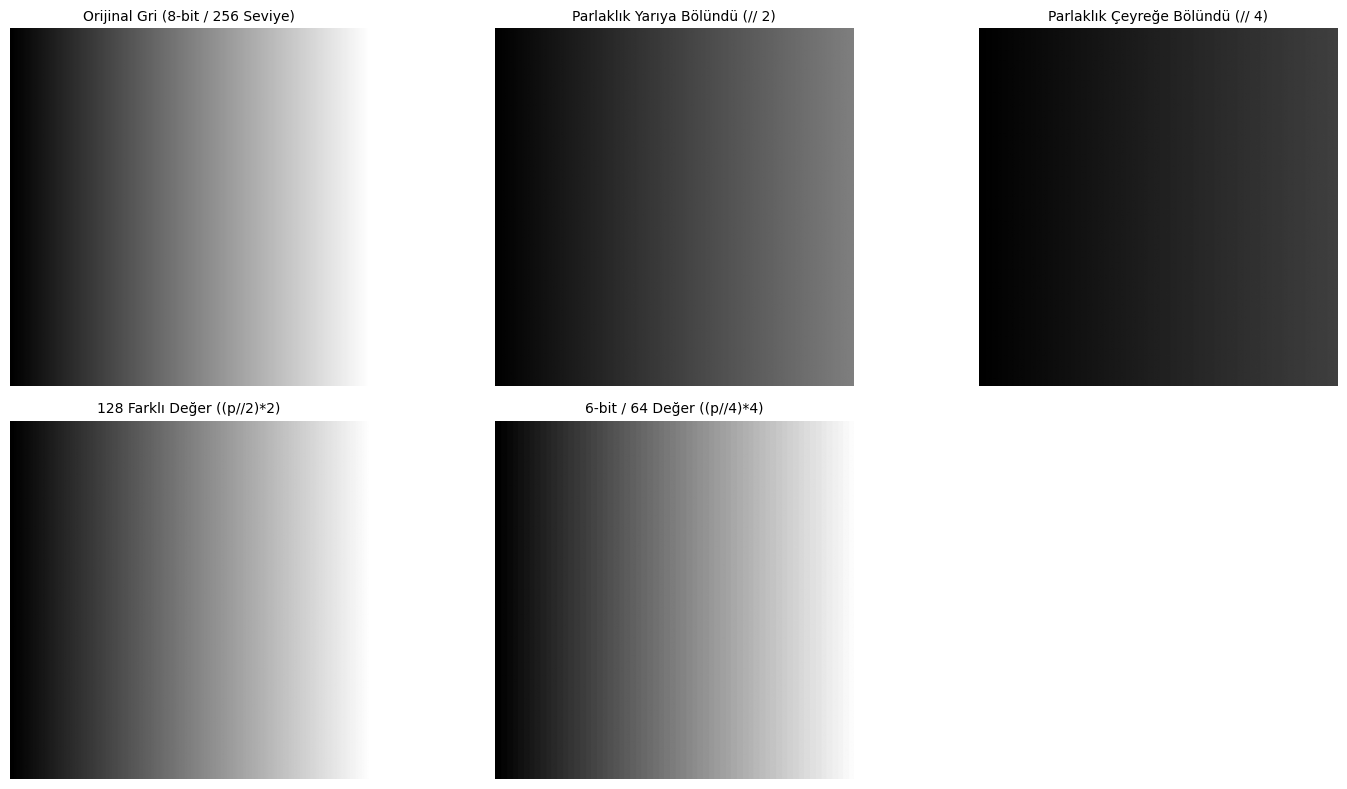

FileNotFoundError: 'insan.jpg' dosyası bulunamadı. Lütfen sol panele görseli yükleyin.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Fotoğrafı oku ve gri tona çevir (Kendi yüklediğin görselin adını yaz)
# Örneğin sol taraftaki panelden 'insan.jpg' yüklediysen:
img_bgr = cv2.imread('insan.jpg')

# Eğer resim yoksa test için otomatik gri bir insan silüeti/tuval oluşturalım:
if img_bgr is None:
    print("Uyarı: 'insan.jpg' bulunamadı, test için örnek bir gri resim oluşturuluyor.")
    img_gray = np.tile(np.linspace(0, 255, 300, dtype=np.uint8), (300, 1))
else:
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

yukseklik, genislik = img_gray.shape

# İşlenmiş yeni resimler için orijinal boyutlarda boş kopyalar oluşturalım
img_yari = np.zeros((yukseklik, genislik), dtype=np.uint8)
img_ceyrek = np.zeros((yukseklik, genislik), dtype=np.uint8)
img_128 = np.zeros((yukseklik, genislik), dtype=np.uint8)
img_6bit = np.zeros((yukseklik, genislik), dtype=np.uint8)

# 2. Satır ve sütunlar için iki ayrı döngü ile pikselleri gezme
for i in range(yukseklik):          # Satırlar
    for j in range(genislik):       # Sütunlar
        p = int(img_gray[i, j])    # Taşmaları önlemek için pikseli int'e çeviriyoruz

        # Parlaklık değerlerini yarıya ve çeyreğe böl
        img_yari[i, j] = p // 2
        img_ceyrek[i, j] = p // 4

        # 256 farklı değer yerine 128 farklı değer (7-bit simülasyonu)
        img_128[i, j] = (p // 2) * 2

        # 4 ile tam sayı bölmesi ve sonra çarpması (64 seviye / 6-bit simülasyonu)
        img_6bit[i, j] = (p // 4) * 4

# 3. Sonuçları yan yana görselleştirme
basliklar = [
    'Orijinal Gri (8-bit / 256 Seviye)',
    'Parlaklık Yarıya Bölündü (// 2)',
    'Parlaklık Çeyreğe Bölündü (// 4)',
    '128 Farklı Değer ((p//2)*2)',
    '6-bit / 64 Değer ((p//4)*4)'
]
resimler = [img_gray, img_yari, img_ceyrek, img_128, img_6bit]

plt.figure(figsize=(15, 8))
for k in range(5):
    plt.subplot(2, 3, k + 1)
    plt.imshow(resimler[k], cmap='gray', vmin=0, vmax=255)
    plt.title(basliklar[k], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
import cv2
import numpy as np
import time

# 1. Fotoğrafı oku ve griye çevir
img_bgr = cv2.imread('insan.jpg')
if img_bgr is None:
    raise FileNotFoundError("'insan.jpg' dosyası bulunamadı. Lütfen sol panele görseli yükleyin.")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
yukseklik, genislik = img_gray.shape

print(f"Resim Boyutu: {genislik}x{yukseklik} ({genislik * yukseklik:,} piksel)\n")

# Hedef boş matrisler
cikis1 = np.zeros_like(img_gray)
cikis2 = np.zeros_like(img_gray)

# -------------------------------------------------------------------------
# DENEY 1: Önce Satırlar (i), Sonra Sütunlar (j) - [Row-Major: Hızlı Olan]
# -------------------------------------------------------------------------
baslangic1 = time.perf_counter()

for i in range(yukseklik):       # Satır
    for j in range(genislik):    # Sütun
        p = int(img_gray[i, j])
        cikis1[i, j] = (p // 4) * 4

bitis1 = time.perf_counter()
sure1 = bitis1 - baslangic1
print(f"1. Yöntem (Satır -> Sütun) Süresi : {sure1:.4f} saniye")

# -------------------------------------------------------------------------
# DENEY 2: Önce Sütunlar (j), Sonra Satırlar (i) - [Column-Major: Yavaş Olan]
# -------------------------------------------------------------------------
baslangic2 = time.perf_counter()

for j in range(genislik):       # Sütun
    for i in range(yukseklik):   # Satır
        p = int(img_gray[i, j])
        cikis2[i, j] = (p // 4) * 4

bitis2 = time.perf_counter()
sure2 = bitis2 - baslangic2
print(f"2. Yöntem (Sütun -> Satır) Süresi : {sure2:.4f} saniye")

# -------------------------------------------------------------------------
# Kıyaslama Raporu
# -------------------------------------------------------------------------
fark = sure2 - sure1
oran = (sure2 / sure1) if sure1 > 0 else 0
print("\n--- Değerlendirme ---")
print(f"Satır-Sütun sırası, Sütun-Satır sırasına göre {oran:.2f} kat daha hızlı çalıştı.")


In [ ]:
import cv2
import numpy as np
import time

# 1. Fotoğrafı oku ve griye çevir
img_bgr = cv2.imread('insan.jpg')
if img_bgr is None:
    raise FileNotFoundError("'insan.jpg' dosyası bulunamadı. Lütfen sol panele görseli yükleyin.")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
yukseklik, genislik = img_gray.shape

print(f"Resim Boyutu: {genislik}x{yukseklik} ({genislik * yukseklik:,} piksel)\n")

# Hedef boş matrisler
cikis1 = np.zeros_like(img_gray)
cikis2 = np.zeros_like(img_gray)

# -------------------------------------------------------------------------
# DENEY 1: Önce Satırlar (i), Sonra Sütunlar (j) - [Row-Major: Hızlı Olan]
# -------------------------------------------------------------------------
baslangic1 = time.perf_counter()

for i in range(yukseklik):       # Satır
    for j in range(genislik):    # Sütun
        p = int(img_gray[i, j])
        cikis1[i, j] = (p // 4) * 4

bitis1 = time.perf_counter()
sure1 = bitis1 - baslangic1
print(f"1. Yöntem (Satır -> Sütun) Süresi : {sure1:.4f} saniye")

# -------------------------------------------------------------------------
# DENEY 2: Önce Sütunlar (j), Sonra Satırlar (i) - [Column-Major: Yavaş Olan]
# -------------------------------------------------------------------------
baslangic2 = time.perf_counter()

for j in range(genislik):       # Sütun
    for i in range(yukseklik):   # Satır
        p = int(img_gray[i, j])
        cikis2[i, j] = (p // 4) * 4

bitis2 = time.perf_counter()
sure2 = bitis2 - baslangic2
print(f"2. Yöntem (Sütun -> Satır) Süresi : {sure2:.4f} saniye")

# -------------------------------------------------------------------------
# Kıyaslama Raporu
# -------------------------------------------------------------------------
fark = sure2 - sure1
oran = (sure2 / sure1) if sure1 > 0 else 0
print("\n--- Değerlendirme ---")
print(f"Satır-Sütun sırası, Sütun-Satır sırasına göre {oran:.2f} kat daha hızlı çalıştı.")

In [ ]:
import cv2
import numpy as np
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Her bir çekirdeğin (Core) çalıştıracağı işlem fonksiyonu
# -------------------------------------------------------------------------
def roi_isle(veri):
    roi, bolum_no = veri
    h, w = roi.shape
    islenmis_roi = np.zeros((h, w), dtype=np.uint8)

    # Satır - Sütun piksellerini gezme
    for i in range(h):
        for j in range(w):
            p = int(roi[i, j])

            if bolum_no == 1:
                # 1. Çeyrek (Sol-Üst): Parlaklığı yarıya böl
                islenmis_roi[i, j] = p // 2
            elif bolum_no == 2:
                # 2. Çeyrek (Sağ-Üst): Parlaklığı çeyreğe böl
                islenmis_roi[i, j] = p // 4
            elif bolum_no == 3:
                # 3. Çeyrek (Sol-Alt): 4-bit (16 seviye) kuantalama
                islenmis_roi[i, j] = (p // 16) * 16
            else:
                # 4. Çeyrek (Sağ-Alt): 2-bit (4 seviye) kuantalama (posterizasyon etkisi)
                islenmis_roi[i, j] = (p // 64) * 64

    return islenmis_roi

# -------------------------------------------------------------------------
# 2. Ana Çalışma Bloğu
# -------------------------------------------------------------------------
if __name__ == '__main__':
    # Resmi oku ve gri tona çevir
    img_bgr = cv2.imread('insan.jpg')
    if img_bgr is None:
        raise FileNotFoundError("'insan.jpg' bulunamadı! Lütfen sol panelden fotoğrafı yüklediğinden emin ol.")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    yukseklik, genislik = img_gray.shape

    # Resmi tam ortadan 4 eşit ROI (alt matris) parçasına böl
    orta_y = yukseklik // 2
    orta_x = genislik // 2

    roi1 = img_gray[0:orta_y, 0:orta_x]          # Sol-Üst
    roi2 = img_gray[0:orta_y, orta_x:genislik]   # Sağ-Üst
    roi3 = img_gray[orta_y:yukseklik, 0:orta_x]  # Sol-Alt
    roi4 = img_gray[orta_y:yukseklik, orta_x:genislik] # Sağ-Alt

    gorevler = [
        (roi1, 1),
        (roi2, 2),
        (roi3, 3),
        (roi4, 4)
    ]

    # Süreyi başlat ve 4 çekirdekle paralel çalıştır
    baslangic = time.perf_counter()

    with Pool(processes=4) as pool:
        sonuclar = pool.map(roi_isle, gorevler)

    bitis = time.perf_counter()
    print(f"4 Çekirdekle Paralel İşleme Süresi: {bitis - baslangic:.4f} saniye")

    # Çekirdeklerden dönen 4 parçayı orijinal boyutunda birleştir
    ust_yari = np.hstack((sonuclar[0], sonuclar[1]))
    alt_yari = np.hstack((sonuclar[2], sonuclar[3]))
    birlestirilmis_resim = np.vstack((ust_yari, alt_yari))

    # Sonuçları ekranda göster
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    plt.title("Orijinal Gri Resim")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(birlestirilmis_resim, cmap='gray', vmin=0, vmax=255)
    plt.title("4 Çekirdekle İşlenmiş 4 Farklı ROI")
    plt.axis('off')

    plt.tight_layout()
    plt.show()



In [ ]:
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Fotoğrafı gri olarak oku
gri_resim = cv2.imread('insan.jpg', cv2.IMREAD_GRAYSCALE)

if gri_resim is None:
  print("Fotoğraf bulunamadı! Lütfen dosya adını ve yolunu kontrol et.")
else:
  islenmis_resim = gri_resim.copy()

  # ROI sınırları
  y_baslangic, y_bitis = 100, 300
  x_baslangic, x_bitis = 150, 350

  # ---------------- ZAMAN ÖLÇÜMÜ BAŞLANGICI ----------------
  baslangic_zamani = time.perf_counter()

  # İşlemi gerçekleştiren döngü
  for i in range(y_baslangic, y_bitis):
    for j in range(x_baslangic, x_bitis):
      piksel = int(islenmis_resim[i, j])
      islenmis_resim[i, j] = piksel // 2  # Parlaklığı yarıya indir

  # ----------------- ZAMAN ÖLÇÜMÜ BİTİŞİ -----------------
  bitis_zamani = time.perf_counter()

  gecen_sure = bitis_zamani - baslangic_zamani
  print(f'ROI döngü çalışma süresi: {gecen_sure:.6f} saniye')
  print(f'Milisaniye cinsinden: {gecen_sure * 1000:.3f} ms')

  # Sonucu göster
  plt.imshow(islenmis_resim, cmap='gray', vmin=0, vmax=255)
  plt.title(f'ROI Değiştirildi (Süre: {gecen_sure * 1000:.2f} ms)')
  plt.axis('off')
  plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Resmi gri seviye olarak oku
img = cv2.imread('insan.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
  print("Fotoğraf bulunamadı! Lütfen dosya adını kontrol et.")
else:
  yukseklik, genislik = img.shape

  # 2. Resmi 2 eşit parçaya ayıralım (Sol ve Sağ Yarı)
  orta_x = genislik // 2

  # Her parlaklık değeri (0 - 255) için piksel sayısını tutacak diziler (Histogramlar)
  hist_sol = np.zeros(256, dtype=int)
  hist_sag = np.zeros(256, dtype=int)

  # --- SOL BÖLGE İÇİN HİSTOGRAM HESABI ---
  for i in range(yukseklik):
    for j in range(0, orta_x):
      deger = img[i, j]
      hist_sol[deger] += 1  # İlgili parlaklık değerinin sayısını 1 artır

  # --- SAĞ BÖLGE İÇİN HİSTOGRAM HESABI ---
  for i in range(yukseklik):
    for j in range(orta_x, genislik):
      deger = img[i, j]
      hist_sag[deger] += 1  # İlgili parlaklık değerinin sayısını 1 artır

  # 3. İKİ PARÇANIN HİSTOGRAMLARINI TOPLA (Tüm Resmin Histogramı)
  hist_toplam = hist_sol + hist_sag

  # Sağlama: Toplam piksel sayısı resmin toplam alanına eşit mi?
  print(f'Sol parçadaki piksel sayısı : {np.sum(hist_sol)}')
  print(f'Sağ parçadaki piksel sayısı : {np.sum(hist_sag)}')
  print(f'Toplam bulunan piksel       : {np.sum(hist_toplam)}')
  print(f'Orijinal resim boyutu (h*w) : {yukseklik * genislik}')

  # 4. GRAFİKLERİ ÇİZDİRME
  plt.figure(figsize=(15, 8))

  # Resmin görseli ve bölme çizgisi
  plt.subplot(2, 2, 1)
  plt.imshow(img, cmap='gray')
  plt.axvline(x=orta_x, color='r', linestyle='--', label='Bölme Çizgisi')
  plt.title('Resim (Sol ve Sağ Parça)')
  plt.legend()
  plt.axis('off')

  # Sol Parçanın Histogramı
  plt.subplot(2, 2, 2)
  plt.bar(range(256), hist_sol, color='blue', width=1.0)
  plt.title('Sol Parçanın Histogramı')
  plt.xlabel('Parlaklık Değeri (0-255)')
  plt.ylabel('Piksel Sayısı')

  # Sağ Parçanın Histogramı
  plt.subplot(2, 2, 3)
  plt.bar(range(256), hist_sag, color='green', width=1.0)
  plt.title('Sağ Parçanın Histogramı')
  plt.xlabel('Parlaklık Değeri (0-255)')
  plt.ylabel('Piksel Sayısı')

  # Birleştirilmiş (Toplam) Histogram
  plt.subplot(2, 2, 4)
  plt.bar(range(256), hist_toplam, color='purple', width=1.0)
  plt.title('Toplam Histogram (Sol + Sağ)')
  plt.xlabel('Parlaklık Değeri (0-255)')
  plt.ylabel('Piksel Sayısı')

  plt.tight_layout()
  plt.show()





In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Fotoğrafı gri olarak oku
gri_resim = cv2.imread('insan.jpg', cv2.IMREAD_GRAYSCALE)

if gri_resim is None:
  print("Fotoğraf bulunamadı! Dosya adını kontrol et.")
else:
  satir_sayisi, sutun_sayisi = gri_resim.shape

  # İşlenmiş piksel değerlerini tutacak yeni boş matris
  yeni_resim = np.zeros((satir_sayisi, sutun_sayisi), dtype=np.uint8)

  # 2. İÇ İÇE DÖNGÜYLE HER PİKSELE İŞLEMİ UYGULA
  for i in range(satir_sayisi):
    for j in range(sutun_sayisi):
      piksel = float(gri_resim[i, j])

      # 0.75 ile çarp ve 20 ekle
      hesaplanan_deger = (piksel * 0.75) + 20

      # Taşmaları önleme (0 ile 255 arasına sabitleme)
      if hesaplanan_deger > 255:
        hesaplanan_deger = 255
      elif hesaplanan_deger < 0:
        hesaplanan_deger = 0

      # Değeri tam sayıya çevirip matrise kaydet
      yeni_resim[i, j] = int(round(hesaplanan_deger))

  # 3. Sonuçları Karşılaştır
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.title('Orijinal Gri Resim')
  plt.imshow(gri_resim, cmap='gray', vmin=0, vmax=255)
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.title('(Piksel * 0.75) + 20')
  plt.imshow(yeni_resim, cmap='gray', vmin=0, vmax=255)
  plt.axis('off')

  plt.tight_layout()
  plt.show()


# Yeni Bölüm